# chap 3

목차
1. 배깅 앙상블
2. 랜덤 포레스트 구현
3. 랜덤 포레스트 매개변수
4. 성능 높이기


## 1. 앙상블과 배깅

랜덤 포레스트, XGBoost는 Decision Tree의 앙상블이다. 다만 트리를 연결하는 방식에 차이가 있다.

XGBoost는 부스팅을 통해 연결하지만, 랜덤 포레스트는 배깅(bagging)을 통해 트리를 연결한다.

차이점은 알겠는데 앙상블 방법이 무엇이고 왜 개별 모델보다 뛰어날까?

### 앙상블 방법(Ensemble Learning)
앞서 만들었던 단일 의사결정나무를 개별 학습기(Base Learner)라고 한다. 앙상블 기법은 개별 학습기 여러 개를 만들어서 묶어버리는 방법이다.
- 왜 합치냐?

하나의 나무에서 학습한 나무는 과대적합의 문제가 있고 permutation_importance에서 확인했듯 사용하지 않는 변수를 놓칠 수 있기 때문이다. 하지만 여러 나무에 조금씩 다른 데이터를 주고 다르게 학습시키면 서로의 약점을 보완한 모델이 나온다.


### 다수결 투표(Voting)
여러 모델이 내놓은 결과를 하나로 합칠 때 다수결 법칙을 이용한다.
- Hard Voting: 더 많은 결과로 결정 ex) 1 예측 10개 0 예측 90개 -> 0
- Soft Voting: 확률의 평균. 각 모델이 예측한 확률을 비교한다.

### 어떻게 구현할까?
1. 사이킷 런의 VotingClassifier을 이용해 사용자가 여러 모델 선택
2. XGBoost나 RandomForest처럼 같은 모델을 여러개 합쳐 놓은 앙상블 사용

### 배깅(bagging)이란?
배깅은 bootstrap aggregation의 약자이다.

- Bootstraping은 중복을 허용한 샘플링(복원추출)을 의미한다. 밑의 그림을 보자. 부트스트랩 샘플 1을 뽑은 후 샘플 2를 뽑을 땐 다시 원본 데이터셋에서 추출한다는 뜻이다.

![bagging](bagging.png)

## 2. 랜덤 포레스트 구현

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

from pathlib import Path
parent_path = Path.cwd().parents[2]
data_dir = parent_path / "04_Resources" / "Dataset" / "XGBoost"
df_census = pd.read_csv(data_dir / "census_cleaned.csv")

# 타깃 변수 분리
y_census = df_census['income_ >50K']
X_census = df_census.drop('income_ >50K', axis=1)

# 구현해 보는 과정이므로 train test 데이터 분리는 생략
rf = RandomForestClassifier(n_estimators=100,
                            random_state=2,
                            n_jobs=-1)

# 교차검증
scores = cross_val_score(rf, X_census, y_census, cv=5) # 기본 점수는 Accuracy
print(f'정확도: {np.round(scores, 3)}')
print(f'정확도 평균: {scores.mean():.3f}')

정확도: [0.858 0.855 0.858 0.862 0.86 ]
정확도 평균: 0.859


XGBoost 만큼은 아니지만 꽤 괜찮은 정확도를 보인다.

이번에는 회귀 모델을 만들어보자

In [3]:
df_bikes = pd.read_csv(data_dir / "bike_rentals_cleaned.csv")
y_bikes = df_bikes['cnt']
X_bikes = df_bikes.drop('cnt', axis=1)

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,
                           random_state=2,
                           n_jobs=-1)
scores = cross_val_score(rf, X_bikes, y_bikes, scoring='neg_root_mean_squared_error', cv=10)
rmse = -scores
print(f'rmse: {np.round(rmse, 3)}')
print(f'rmse 평균: {rmse.mean():.3f}')

rmse: [ 808.463  525.428  539.539  815.262  884.849  840.782  806.523  811.871
  791.273 2160.373]
rmse 평균: 898.436


다른 모델들과 비교해서 엄청 좋은 수치는 아님. 왜 그런지는 후반부에 설명

## 3. 랜덤 포레스트 매개변수

### oob_score

배깅은 랜덤 복원 추출 이므로 선택되지 않은 데이터가 남아있다. 이 데이터들을 Out Of Bag 샘플이라고 하는데 1번 나무의 훈련이 끝나면 OOB 샘플을 넣어서 검증, 2번 3번 ... 이렇게 모든 나무가 이 과정을 거치면 OOB샘플의 예측 정확도가 oob_score_ 속성에 저장된다.
따라서 검증 데이터(Validation Set)을 절약할 수 있다. 이 점수는 교차 검증 점수와 매우 유사한 결과를 낸다.
- 분류: Accuracy
- 회귀: 결정계수($R^2$)

In [4]:
rf = RandomForestClassifier(oob_score=True, n_estimators=100, random_state=2, n_jobs=-1)
rf.fit(X_census, y_census) # 학습을 하면서 oob_score_ 생성
rf.oob_score_

0.8551334418476091

위의 교차 검증 정확도와 비슷하다!
- 제미나이 曰: 만약oob_score_는 매우 높은데 test_score가 낮다면, 이는 모델이 훈련 데이터의 특수한 구조에 과적합(Overfitting)되었을 가능성을 시사하는 아주 좋은 힌트가 됩니다.

### n_estimators

몇 개의 트리를 만들지 설정한다. 기본값은 100개로 데이터셋이 크면 500개 이상이 필요할 수 있다.

### warm_start

warm_start=True로 지정하면 이전에 만들어둔 트리에 이어서 학습한다.

n_estimators = 100으로 설정했다가 200으로 바꾸면 처음부터 학습하는게 아니라 원래 100개에서 이어서 나머지 100개를 만든다.

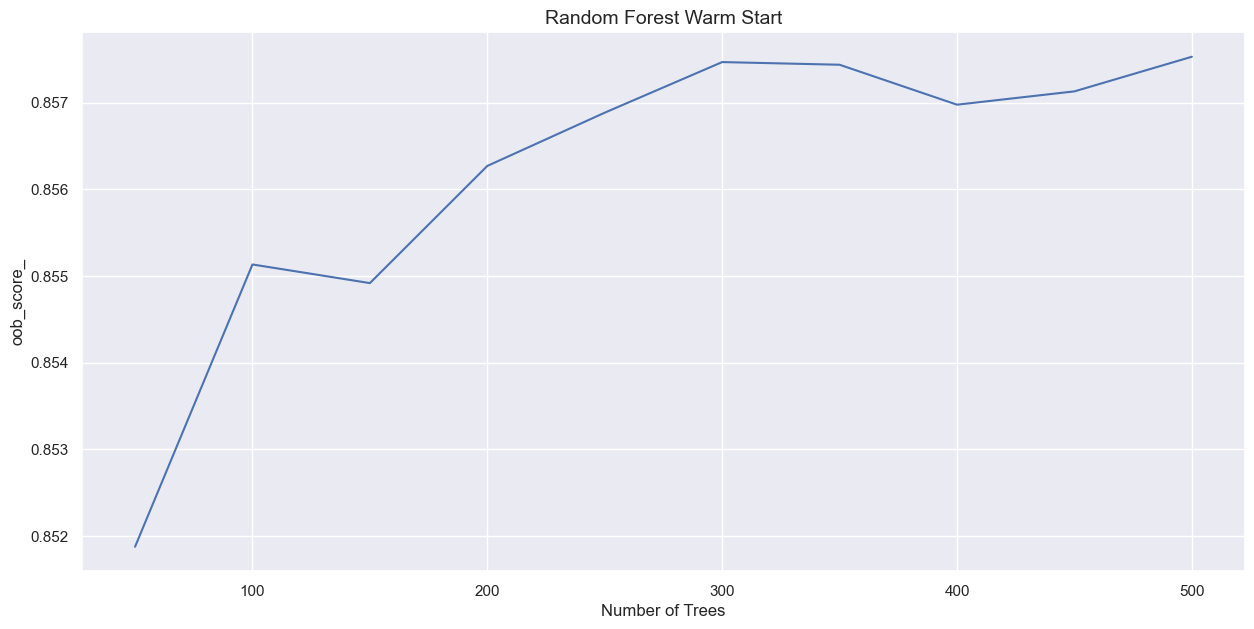

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
oob_scores = []
rf = RandomForestClassifier(n_estimators=50, warm_start=True, oob_score=True, n_jobs=-1, random_state=2)
rf.fit(X_census, y_census)
oob_scores.append(rf.oob_score_)
est=50
estimators=[est]
for i in range(9):
    est += 50
    estimators.append(est)
    rf.set_params(n_estimators=est)
    rf.fit(X_census, y_census)
    oob_scores.append(rf.oob_score_)
    
plt.figure(figsize=(15,7))
plt.plot(estimators, oob_scores)
plt.xlabel('Number of Trees')
plt.ylabel('oob_score_')
plt.title('Random Forest Warm Start', fontsize=14)
plt.show()

트리는 300개가 적당하다는 것을 알 수 있다.

### bootstrap

복원추출 끄기. 따라서 oob_score_ 속성도 없어짐

### verbose

기본값은 0으로 숫자를 조정하면 모델 제작 시 여러 정보를 출력한다.

### 결정 트리 매개변수

나머지 매개변수는 Decision Tree의 매개변수이다.
1. 트리 깊이
- max_depth
2. 분할
- max_features: 분할에 사용할 특성 개수
- min_sample_split: 분할에 필요한 최소 샘플 개수
- min_impurity_decrease: 분할에 필요한 최소 불순도 감소량
3. 리프 노드
- min_samples_leaf: 리프 노드가 되기 위한 최소 샘플 개수
- min_weight_fraction_leaf: 리프 노드가 되기 위한 최소 샘플 개수 비율

## 4. 성능 높이기


조금전 자전거 대여 횟수 예측 문제에서 rmse: 898점을 받았다.

튜닝을 통하여 최대한 rmse를 낮춰보자

### 1. train/test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_bikes, y_bikes, random_state=2
)

### 2. n_estimators 선택하기

c:\Users\devsa\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Text(0.5, 1.0, 'Random Forest Warm Start')

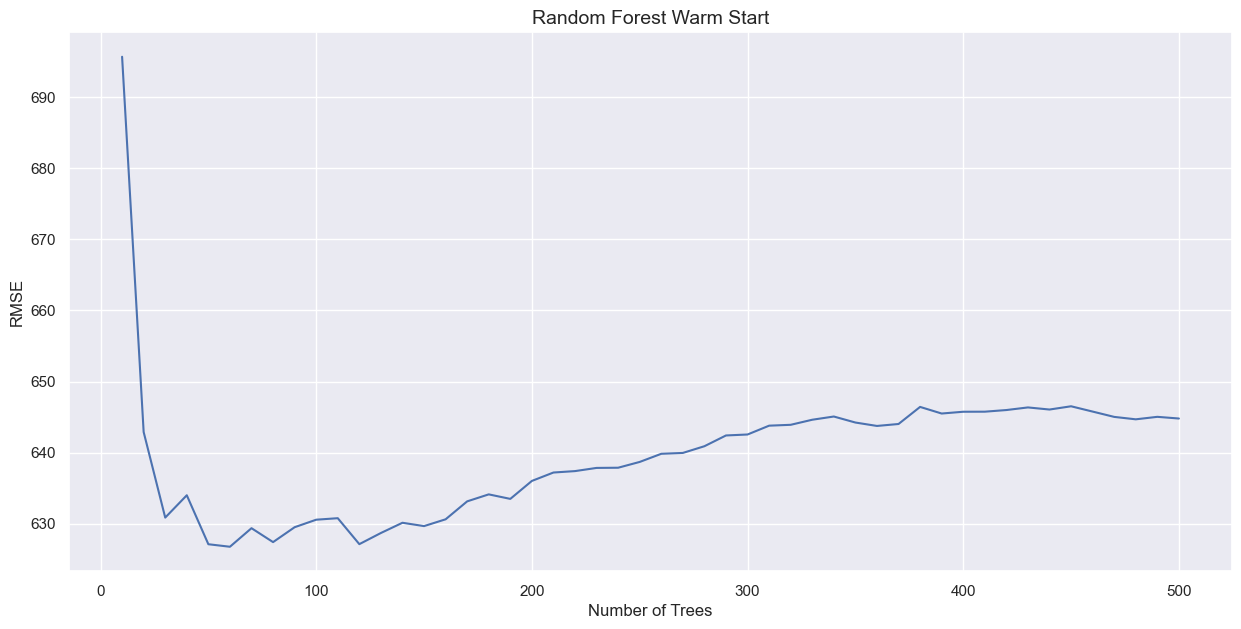

In [9]:
from sklearn.metrics import root_mean_squared_error
sns.set_theme()
rmse_list = []
est_list = []
rf = RandomForestRegressor(n_estimators=10, warm_start=True, oob_score=True, n_jobs=-1, random_state=2)
est = 10

for i in range(50):
    rf.set_params(n_estimators=est)
    rf.fit(X_train, y_train)
    rmse = root_mean_squared_error(y_test, rf.predict(X_test))
    rmse_list.append(rmse)
    est_list.append(est)
    est += 10

plt.figure(figsize=(15,7))
plt.plot(est_list, rmse_list)
plt.xlabel('Number of Trees')
plt.ylabel('RMSE')
plt.title('Random Forest Warm Start', fontsize=14)


50정도가 적당한것 같은데 한번 오름차순 정렬을 해보자

In [16]:
rmse_df = pd.DataFrame({'Trees':est_list,
                        'RMSE': rmse_list})
rmse_df.sort_values(['RMSE'])

,Trees,RMSE
5,60,626.753950
4,50,627.108328
11,120,627.119613
7,80,627.406772
12,130,628.689120
6,70,629.364504
8,90,629.503320
14,150,629.659325
13,140,630.128604
9,100,630.559309


**주의: 공모전처럼 실제 테스트 데이터가 따로 있는게 아니면 절대로 위 방식처럼 테스트 세트로 매개변수를 튜닝해서는 안됨**

### 3. 교차 검증 해보기

In [19]:
rf = RandomForestRegressor(n_estimators=50, warm_start=True, n_jobs=-1, random_state=2)
scores = cross_val_score(rf, X_bikes, y_bikes, scoring='neg_root_mean_squared_error', cv=10)
rmse = -scores
print(f"RMSE: {np.round(rmse, 3)}")
print(f"RMSE 평균: {np.mean(rmse):.2f}")

RMSE: [ 834.693  542.614  533.485  826.827  896.435  870.934  788.422  832.447
  769.759 2137.915]
RMSE 평균: 903.35


마지막 폴드의 에러가 이상하다. 이런 경우는 보통 데이터의 오류나 이상치(outlier 문제이다)

### 4. 하이퍼파라미터 튜닝

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error
def random_search_reg(params, runs=16,
                      reg=RandomForestRegressor(random_state=2, n_jobs=-1)):
    rand_reg = RandomizedSearchCV(reg, params, n_iter=runs,
                                  scoring=('neg_root_mean_squared_error'), cv=10,
                                  n_jobs=-1, random_state=2)
    rand_reg.fit(X_train, y_train)
    best_model = rand_reg.best_estimator_
    best_params = rand_reg.best_params_
    best_score = -rand_reg.best_score_
    print(f"best_params: {best_params}")
    print(f"best_score: {best_score}")
    print(f"test_score: {root_mean_squared_error(y_test, best_model.predict(X_test))}")

첫 번째 탐색을 해보자

In [21]:
random_search_reg(
    params={'min_weight_fraction_leaf':[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.05],
            'min_samples_split':[2, 0.01, 0.02, 0.03, 0.04, 0.06, 0.08, 0.1],
            'min_samples_leaf':[1,2,4,6,8,10,20,30],
            'min_impurity_decrease':[0.0, 0.01, 0.05, 0.10, 0.15, 0.2],
            'max_leaf_nodes':[10, 15, 20, 25, 30, 35, 40, 45, 50, None],
            'max_features':['sqrt', 0.8, 0.7, 0.6, 0.5, 0.4],
            'max_depth':[None,2,4,6,8,10,20]})

best_params: {'min_weight_fraction_leaf': 0.0, 'min_samples_split': 0.03, 'min_samples_leaf': 6, 'min_impurity_decrease': 0.05, 'max_leaf_nodes': 25, 'max_features': 0.7, 'max_depth': None}
best_score: 746.3346731798816
test_score: 702.0068246419838


상당히 성능이 좋아졌다. 범위를 좁혀서 두 번째 탐색을 해보자

In [22]:
random_search_reg(
    params={'min_samples_leaf':[1,2,4,6,8,10,20,30],
            'min_impurity_decrease':[0.0, 0.01, 0.05, 0.10, 0.15, 0.2],
            'max_features':['sqrt', 0.8, 0.7, 0.6, 0.5, 0.4],
            'max_depth':[None,2,4,6,8,10,20]})

best_params: {'min_samples_leaf': 1, 'min_impurity_decrease': 0.1, 'max_features': 0.6, 'max_depth': 10}
best_score: 668.235330804091
test_score: 625.7962181882549


더 좋아졌다. 범위를 더 좁히고 새로운 파라미터를 추가해보자

In [23]:
random_search_reg(
    params={'min_samples_leaf':[1,2,4,6,8,10,20,30],
            'min_impurity_decrease':[0.0, 0.01, 0.05, 0.10, 0.15, 0.2],
            'max_features':['sqrt', 0.8, 0.7, 0.6, 0.5, 0.4],
            'max_depth':[None,4,6,8,10,12,15,20]},
    runs=20)

best_params: {'min_samples_leaf': 1, 'min_impurity_decrease': 0.1, 'max_features': 0.6, 'max_depth': 12}
best_score: 664.2524989125911
test_score: 621.1932713427854


다시 범위를 좁히기

In [24]:
random_search_reg(
    params={'min_samples_leaf':[1,2,3,4,5,6],
            'min_impurity_decrease':[0.0, 0.01, 0.05, 0.08, 0.10, 0.12, 0.15],
            'max_features':['sqrt', 0.8, 0.7, 0.6, 0.5, 0.4],
            'max_depth':[None,8,10,12,14,16,18,20]})

best_params: {'min_samples_leaf': 1, 'min_impurity_decrease': 0.05, 'max_features': 0.7, 'max_depth': 18}
best_score: 671.440097835727
test_score: 631.0165171008655


이번에는 조금 나빠졌다. n_estimators를 증가시켜보자

In [25]:
random_search_reg(
    params={'min_samples_leaf':[1,2,3,4,5,6],
            'min_impurity_decrease':[0.0, 0.01, 0.05, 0.08, 0.10, 0.12, 0.15],
            'max_features':['sqrt', 0.8, 0.7, 0.6, 0.5, 0.4],
            'max_depth':[None,8,10,12,14,16,18,20],
            'n_estimators':[50, 60, 100]},
    runs=20)

best_params: {'n_estimators': 60, 'min_samples_leaf': 1, 'min_impurity_decrease': 0.0, 'max_features': 0.5, 'max_depth': 12}
best_score: 666.2949222704367
test_score: 606.9359351137435


계속해서 튜닝을 한 결과 600 근처의 점수를 얻을 수 있었다. 이제 교차검증으로 결과를 확인해보자

In [27]:
rf = RandomForestRegressor(n_estimators=60, min_samples_leaf=1, min_impurity_decrease=0.0, max_features=0.5, max_depth=12)
scores = cross_val_score(rf, X_bikes, y_bikes, scoring='neg_root_mean_squared_error', cv=10)
rmse = -scores
print(f"RMSE: {np.round(rmse, 3)}")
print(f"RMSE 평균: {np.mean(rmse):.2f}")

RMSE: [ 821.881  540.637  546.496  817.667  765.71   823.916  866.979  802.32
  762.281 1671.984]
RMSE 평균: 841.99


분명히 좋아졌긴 했는데 마지막 분할에 문제가 있는것같다. 여기서는 데이터를 섞는게 도움이 되는지 관찰해보자

In [28]:
from sklearn.utils import shuffle
df_shuffle_bikes = shuffle(df_bikes, random_state=2)
y_bikes_s = df_shuffle_bikes['cnt']
X_bikes_s = df_shuffle_bikes.drop('cnt', axis=1)

rf = RandomForestRegressor(n_estimators=60, min_samples_leaf=1, min_impurity_decrease=0.0, max_features=0.5, max_depth=12)
scores = cross_val_score(rf, X_bikes_s, y_bikes_s, scoring='neg_root_mean_squared_error', cv=10)
rmse = -scores
print(f"RMSE: {np.round(rmse, 3)}")
print(f"RMSE 평균: {np.mean(rmse):.2f}")

RMSE: [643.503 692.493 453.526 555.432 620.322 710.662 810.096 651.29  715.685
 610.534]
RMSE 평균: 646.35


확실히 폴드 간의 점수 폭이 안정적이다.

이상치 제거나 피처 엔지니어링을 통해서도 점수를 더 개선 시킬 여지가 보인다.

### 랜덤 포레스트 모델의 단점!


방금 전의 사례에서 봤듯이 개별 트리가 저지른 실수를 그대로 학습한다. 이 단점을 보완한 부스팅 기법은 트리의 실수를 학습하는데, 위와 같이 섞지 않은 데이터의 경우에서는 튜닝을 하지 않은 부스팅 모델이 더 강력할 수도 있다.
chapter4에서는 그레이디언트 부스팅의 작동 방식에 대해서 알아본다.